# Notebook 4 — Learning slope by sex and circadian classification

Old animals only. Circadian classification is the **directional composite split**
from Notebook 2 (`dysfunction_score`, median split): higher composite z-score
=> **Vulnerable**; otherwise **Resilient**.

This notebook:
1. Loads the per-animal classification CSV and merges Barnes learning slopes.
2. Plots learning slope by Sex x circadian_group (bar + SEM + dot overlay).
3. Plots the **percentage of old males vs old females** classified as Vulnerable.
4. Runs a 2-way ANOVA (Sex x circadian_group) on learning slope.
5. Addresses whether z-scoring would help with the unbalanced cell sizes.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

sns.set_context("notebook")
sns.set_style("whitegrid")

HERE = Path.cwd()                      # poster_analysis/vulnerability_resilience_analysis/
REPO = HERE.parent.parent

df = pd.read_csv(HERE / "dysfunction_classifications.csv")
slopes = pd.read_csv(REPO / "learning_slopes_per_mouse.csv")[["ID", "learning_slope"]]
df = df.merge(slopes, on="ID", how="left")

# Normalise label casing so plots show "Resilient" / "Vulnerable"
df["circadian_group"] = df["circadian_group"].str.capitalize()

print(f"Old animals total: n = {len(df)}")
print(f"With learning slope + circadian group: n = "
      f"{df.dropna(subset=['learning_slope','circadian_group']).shape[0]}")

ORDER_X    = ["Female", "Male"]
ORDER_HUE  = ["Resilient", "Vulnerable"]
PALETTE    = {"Resilient": "#aff0b6", "Vulnerable": "#ddee93"}
SEX_COLORS = {"Female": "#e81414", "Male": "#0c8fd5"}


Old animals total: n = 40
With learning slope + circadian group: n = 38


## 1. Bar chart — learning slope by Sex x circadian_group

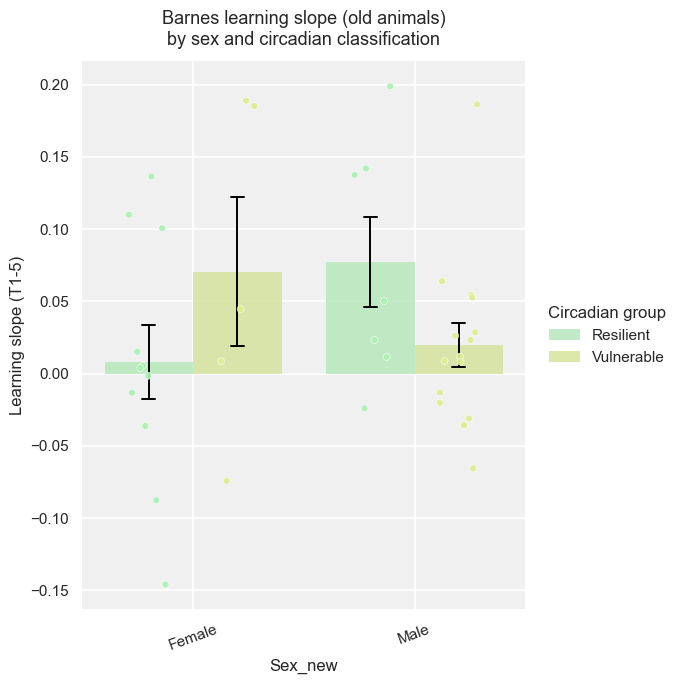


Mean +/- SEM:
                          mean    sem  count
Sex_new circadian_group                     
Female  Resilient        0.008  0.025     11
        Vulnerable       0.071  0.051      5
Male    Resilient        0.077  0.031      7
        Vulnerable       0.020  0.015     15


In [2]:
plot_df = df.dropna(subset=["learning_slope", "circadian_group", "Sex_new"]).copy()

fig, ax = plt.subplots(figsize=(7, 7))

sns.barplot(
    data=plot_df, x="Sex_new", y="learning_slope", hue="circadian_group",
    order=ORDER_X, hue_order=ORDER_HUE, palette=PALETTE,
    errorbar="se", capsize=0.12, err_kws={"linewidth": 1.4, "color": "black"},
    edgecolor="none", alpha=0.85, ax=ax,
)
sns.stripplot(
    data=plot_df, x="Sex_new", y="learning_slope", hue="circadian_group",
    order=ORDER_X, hue_order=ORDER_HUE, palette=PALETTE,
    dodge=True, jitter=0.18, size=5, alpha=0.95,
    edgecolor="white", linewidth=0.4, ax=ax, legend=False,
)

ax.set_title("Barnes learning slope (old animals)\nby sex and circadian classification",
             fontsize=13, pad=12)
ax.set_xlabel("Sex_new"); ax.set_ylabel("Learning slope (T1-5)")
ax.tick_params(axis="x", labelrotation=20)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Circadian group",
          loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.set_facecolor("#f0f0f0")
for s in ax.spines.values(): s.set_visible(False)
ax.grid(True, color="white", linewidth=1.2)
plt.tight_layout(); plt.show()

print("\nMean +/- SEM:")
print(plot_df.groupby(["Sex_new", "circadian_group"])["learning_slope"]
      .agg(["mean", "sem", "count"]).round(3).to_string())


## 2. Percentage of Vulnerable animals — old males vs old females

Same circadian classification, just summarised as a sex-level proportion.
This makes the cell-size imbalance visible (which then matters for the ANOVA).


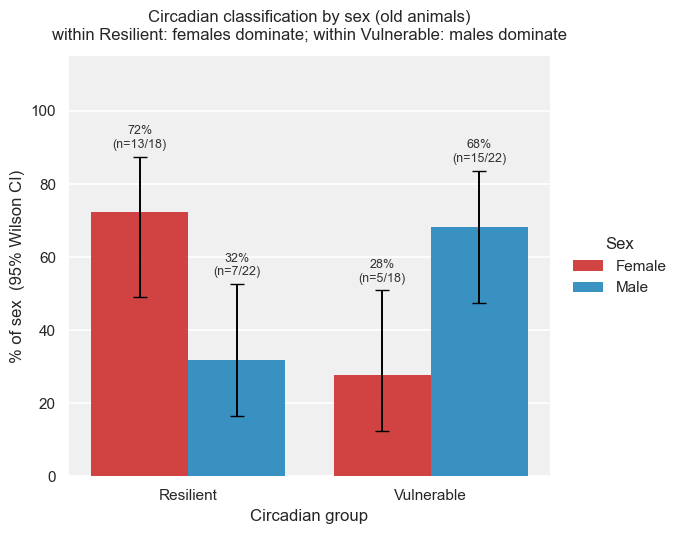

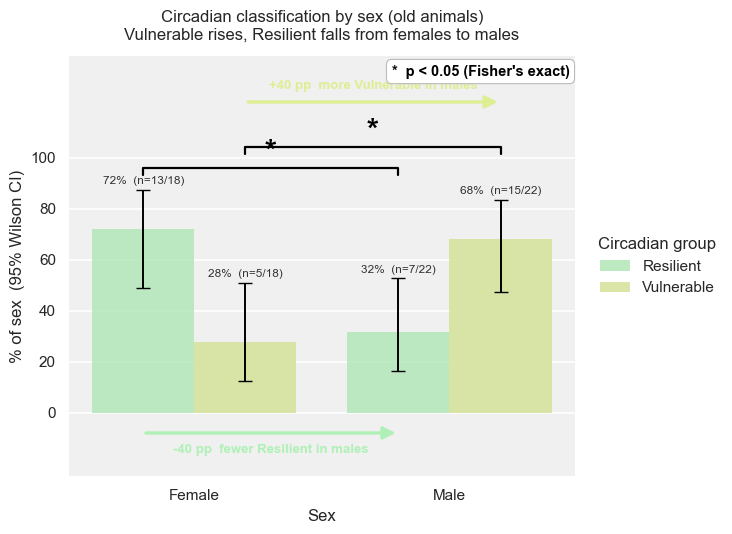

Contingency table:
circadian_group  Resilient  Vulnerable
Sex_new                               
Female                  13           5
Male                     7          15

Chi-squared(Sex x circadian_group) = 4.95, dof=1, p=0.0261
Fisher's exact: odds ratio = 5.57, p = 0.0248


In [3]:
from statsmodels.stats.proportion import proportion_confint

pct_df = df.dropna(subset=["circadian_group"]).copy()
rows = []
for sex in ORDER_X:
    sub = pct_df[pct_df["Sex_new"] == sex]
    n_total = len(sub)
    for grp in ORDER_HUE:
        k = (sub["circadian_group"] == grp).sum()
        p_hat = k / n_total * 100 if n_total else np.nan
        lo, hi = proportion_confint(k, n_total, alpha=0.05, method="wilson")
        rows.append({"Sex_new": sex, "circadian_group": grp,
                     "pct": p_hat, "n": k, "n_total": n_total,
                     "lo": lo*100, "hi": hi*100})
pct = pd.DataFrame(rows)

SEX_PALETTE = SEX_COLORS  # red Female, blue Male
GROUP_ORDER = ORDER_HUE  # ["Resilient", "Vulnerable"]
SEX_ORDER   = ORDER_X    # ["Female", "Male"]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.barplot(
    data=pct, x="circadian_group", y="pct", hue="Sex_new",
    order=GROUP_ORDER, hue_order=SEX_ORDER, palette=SEX_PALETTE,
    edgecolor="none", alpha=0.9, ax=ax,
)

# Wilson 95% CI error bars + label per bar
for bar, (sex, grp) in zip(
        ax.patches,
        [(s, g) for s in SEX_ORDER for g in GROUP_ORDER]):
    row = pct[(pct["Sex_new"] == sex) & (pct["circadian_group"] == grp)].iloc[0]
    x = bar.get_x() + bar.get_width()/2
    ax.errorbar(x, row["pct"],
                yerr=[[row["pct"] - row["lo"]], [row["hi"] - row["pct"]]],
                fmt="none", ecolor="black", elinewidth=1.4, capsize=5)
    ax.text(x, row["hi"] + 1.5,
            f"{row['pct']:.0f}%\n(n={int(row['n'])}/{int(row['n_total'])})",
            ha="center", va="bottom", fontsize=9, color="#333")

ax.set_title("Circadian classification by sex (old animals)\n"
             "within Resilient: females dominate; within Vulnerable: males dominate",
             fontsize=12, pad=12)
ax.set_xlabel("Circadian group"); ax.set_ylabel("% of sex  (95% Wilson CI)")
ax.set_ylim(0, 115)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.legend(title="Sex", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.set_facecolor("#f0f0f0")
for s in ax.spines.values(): s.set_visible(False)
ax.grid(True, color="white", linewidth=1.2, axis="y")
plt.tight_layout(); plt.show()

# ---------- Alternate view: x = Sex, hue = circadian_group, with trend arrows ----------
ALT_PALETTE = PALETTE       # standardised: light green / yellow-green
ALT_X       = ORDER_X
ALT_HUE     = ORDER_HUE

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.barplot(
    data=pct, x="Sex_new", y="pct", hue="circadian_group",
    order=ALT_X, hue_order=ALT_HUE, palette=ALT_PALETTE,
    edgecolor="none", alpha=0.9, ax=ax,
)
for bar, (grp, sex) in zip(
        ax.patches,
        [(g, s) for g in ALT_HUE for s in ALT_X]):
    row = pct[(pct["Sex_new"] == sex) & (pct["circadian_group"] == grp)].iloc[0]
    x = bar.get_x() + bar.get_width()/2
    ax.errorbar(x, row["pct"],
                yerr=[[row["pct"] - row["lo"]], [row["hi"] - row["pct"]]],
                fmt="none", ecolor="black", elinewidth=1.4, capsize=5)
    ax.text(x, row["hi"] + 1.5,
            f"{row['pct']:.0f}%  (n={int(row['n'])}/{int(row['n_total'])})",
            ha="center", va="bottom", fontsize=8.5, color="#333")

def _bar_xcenter(sex, grp):
    j = ALT_X.index(sex); k = ALT_HUE.index(grp)
    return j + (-0.2 if k == 0 else 0.2)

vul_F = pct[(pct["Sex_new"]=="Female") & (pct["circadian_group"]=="Vulnerable")].iloc[0]
vul_M = pct[(pct["Sex_new"]=="Male")   & (pct["circadian_group"]=="Vulnerable")].iloc[0]
res_F = pct[(pct["Sex_new"]=="Female") & (pct["circadian_group"]=="Resilient")].iloc[0]
res_M = pct[(pct["Sex_new"]=="Male")   & (pct["circadian_group"]=="Resilient")].iloc[0]

# Trend arrows in dedicated whitespace bands above and below the bars.
TOP_Y = 122
BOT_Y = -8

ax.annotate("", xy=(_bar_xcenter("Male", "Vulnerable"), TOP_Y),
            xytext=(_bar_xcenter("Female", "Vulnerable"), TOP_Y),
            arrowprops=dict(arrowstyle="-|>", color=ALT_PALETTE["Vulnerable"],
                            lw=2.4, mutation_scale=18))
ax.text((_bar_xcenter("Female", "Vulnerable") + _bar_xcenter("Male", "Vulnerable"))/2,
        TOP_Y + 4,
        f"+{vul_M['pct'] - vul_F['pct']:.0f} pp  more Vulnerable in males",
        ha="center", va="bottom", fontsize=9.5,
        color=ALT_PALETTE["Vulnerable"], fontweight="bold")

ax.annotate("", xy=(_bar_xcenter("Male", "Resilient"), BOT_Y),
            xytext=(_bar_xcenter("Female", "Resilient"), BOT_Y),
            arrowprops=dict(arrowstyle="-|>", color=ALT_PALETTE["Resilient"],
                            lw=2.4, mutation_scale=18))
ax.text((_bar_xcenter("Female", "Resilient") + _bar_xcenter("Male", "Resilient"))/2,
        BOT_Y - 4,
        f"{res_M['pct'] - res_F['pct']:.0f} pp  fewer Resilient in males",
        ha="center", va="top", fontsize=9.5,
        color=ALT_PALETTE["Resilient"], fontweight="bold")

# ---------------- Significance brackets where the test is actually significant ----------------
# Fisher's exact on the 2x2 table -> p = 0.025, OR = 5.57. The same test is
# expressed visually by the F-resilient vs M-resilient gap AND the F-vulnerable
# vs M-vulnerable gap, so we draw a bracket on each pair.
def _bracket(ax, x1, x2, y, label, h=2.5, fontsize=22, color="black", lw=1.6):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, color=color)
    ax.text((x1+x2)/2, y+h+0.5, label, ha="center", va="bottom",
            fontsize=fontsize, color=color, fontweight="bold")

# Big, bold asterisk over each bracket
LABEL = "*"

# Resilient: F-resilient (72%) vs M-resilient (32%)
_bracket(ax,
         _bar_xcenter("Female", "Resilient"), _bar_xcenter("Male", "Resilient"),
         y=max(res_F["hi"], res_M["hi"]) + 6, label=LABEL, color="black")

# Vulnerable: F-vulnerable (28%) vs M-vulnerable (68%) — drawn slightly higher
_bracket(ax,
         _bar_xcenter("Female", "Vulnerable"), _bar_xcenter("Male", "Vulnerable"),
         y=max(vul_F["hi"], vul_M["hi"]) + 18, label=LABEL, color="black")

# Legend explaining the asterisk (drawn as figure-level text inside the axes box)
ax.text(0.99, 0.98, "*  p < 0.05 (Fisher's exact)",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10.5, fontweight="bold", color="black",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor="#bbbbbb", linewidth=0.8))

ax.set_title("Circadian classification by sex (old animals)\n"
             "Vulnerable rises, Resilient falls from females to males",
             fontsize=12, pad=12)
ax.set_xlabel("Sex"); ax.set_ylabel("% of sex  (95% Wilson CI)")
ax.set_ylim(-25, 140)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.legend(title="Circadian group", loc="center left", bbox_to_anchor=(1.02, 0.5),
          frameon=False)
ax.set_facecolor("#f0f0f0")
for s in ax.spines.values(): s.set_visible(False)
ax.grid(True, color="white", linewidth=1.2, axis="y")
plt.tight_layout(); plt.show()

# Chi-squared test on the 2x2 (Sex x circadian_group)
tab = pd.crosstab(df["Sex_new"], df["circadian_group"])
print("Contingency table:\n", tab, sep="")
chi2, p, dof, _ = stats.chi2_contingency(tab)
print(f"\nChi-squared(Sex x circadian_group) = {chi2:.2f}, dof={dof}, p={p:.4f}")
odds, p_fish = stats.fisher_exact(tab.values)
print(f"Fisher's exact: odds ratio = {odds:.2f}, p = {p_fish:.4f}")


## 3. Two-way ANOVA — Sex x circadian_group on learning slope

Type III SS so the unbalanced cells (F: 11 res / 5 vul; M: 7 res / 15 vul) are
handled correctly. We also report Levene's test (variance equality) and the
descriptive cell means; an interaction term is included because the bar chart
suggests the effect of vulnerability flips sign between sexes.


In [4]:
mod = smf.ols("learning_slope ~ C(Sex_new) * C(circadian_group)",
              data=plot_df).fit()
anova = sm.stats.anova_lm(mod, typ=3)
print("Type III ANOVA:\n", anova.round(4), sep="")

# Levene's test (variance homogeneity across the four cells)
groups = [g["learning_slope"].values
          for _, g in plot_df.groupby(["Sex_new", "circadian_group"])]
W, p_lev = stats.levene(*groups, center="median")
print(f"\nLevene's test (median-centered): W = {W:.3f}, p = {p_lev:.4f}")

print("\nCell means (sanity check):")
print(plot_df.groupby(['Sex_new','circadian_group'])['learning_slope']
      .agg(['mean','sem','count']).round(3).to_string())


Type III ANOVA:
                               sum_sq    df       F  PR(>F)
Intercept                      0.0007   1.0  0.1117  0.7403
C(Sex_new)                     0.0204   1.0  3.2708  0.0794
C(circadian_group)             0.0135   1.0  2.1635  0.1505
C(Sex_new):C(circadian_group)  0.0287   1.0  4.5930  0.0393
Residual                       0.2123  34.0     NaN     NaN

Levene's test (median-centered): W = 1.301, p = 0.2901

Cell means (sanity check):
                          mean    sem  count
Sex_new circadian_group                     
Female  Resilient        0.008  0.025     11
        Vulnerable       0.071  0.051      5
Male    Resilient        0.077  0.031      7
        Vulnerable       0.020  0.015     15


### Interaction plot — visualising Sex x circadian_group  (F = 4.59, p = 0.039)

Cell means with SEM error bars and individual mice overlaid as dots; lines connect
the two circadian groups within each sex so the *crossover* (the interaction) is
visible at a glance.


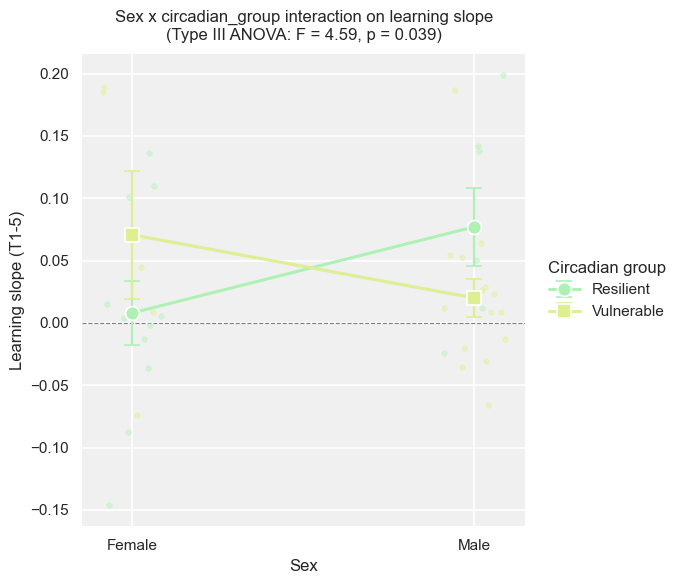

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

# Sex on x-axis; circadian_group as the line.
GROUP_COLOR  = PALETTE
GROUP_MARKER = {"Resilient": "o", "Vulnerable": "s"}

# Individual points (jittered), coloured by circadian group
for j, sex in enumerate(ORDER_X):
    for grp in ORDER_HUE:
        sub = plot_df[(plot_df["Sex_new"] == sex) & (plot_df["circadian_group"] == grp)]
        rng = np.random.default_rng(42 + j*10 + ORDER_HUE.index(grp))
        xs  = j + (rng.random(len(sub)) - 0.5) * 0.18
        ax.scatter(xs, sub["learning_slope"].values, s=28,
                   color=GROUP_COLOR[grp], alpha=0.45, edgecolor="white",
                   linewidth=0.5, zorder=2)

# Cell means + SEM, one line per circadian group, plotted across Sex on x.
for grp in ORDER_HUE:
    means, sems, xs = [], [], []
    for j, sex in enumerate(ORDER_X):
        sub = plot_df[(plot_df["Sex_new"] == sex) & (plot_df["circadian_group"] == grp)]
        means.append(sub["learning_slope"].mean())
        sems.append(sub["learning_slope"].sem())
        xs.append(j)
    ax.errorbar(xs, means, yerr=sems, fmt=GROUP_MARKER[grp] + "-",
                color=GROUP_COLOR[grp], ecolor=GROUP_COLOR[grp],
                elinewidth=1.6, capsize=6, markersize=10, linewidth=2.2,
                label=grp, zorder=4, markeredgecolor="white", markeredgewidth=1.2)

ax.set_xticks([0, 1]); ax.set_xticklabels(ORDER_X)
ax.set_xlabel("Sex"); ax.set_ylabel("Learning slope (T1-5)")
ax.set_title("Sex x circadian_group interaction on learning slope\n"
             "(Type III ANOVA: F = 4.59, p = 0.039)", fontsize=12, pad=10)
ax.legend(title="Circadian group", loc="center left",
          bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.set_facecolor("#f0f0f0")
for s in ax.spines.values(): s.set_visible(False)
ax.grid(True, color="white", linewidth=1.2)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", zorder=1)
plt.tight_layout(); plt.show()


## 4. Should we z-score to account for the unbalanced cell sizes?

**Short answer: no.** Z-scoring is a rescaling, not a fix for unbalanced n.

| What z-scoring does | What unbalanced n needs |
|---|---|
| Centres and rescales a variable so it has mean 0, SD 1 | Different sums-of-squares decomposition (Type II / III) so the test does not depend on the order of factors |
| Removes location/scale information | Preserves location/scale but accounts for cell-size imbalance |

A few specific cases:

- **Z-score `learning_slope` overall.** Just rescales y. The F-statistic and p-values from the ANOVA are *identical* — you have not addressed anything.
- **Z-score `learning_slope` within sex.** Forces every sex to have mean 0, SD 1.
  This *destroys* the main effect of Sex by construction and shrinks/inflates the
  Sex x group interaction depending on within-sex variance. This is the wrong
  move when Sex is one of the factors you are testing.
- **Z-score `learning_slope` within circadian_group.** Same problem mirrored —
  destroys the main effect of group.

**What actually handles unbalanced n:** the Type III ANOVA above, which uses
the partial sums of squares so each effect is tested adjusting for all the
others. With n=5 in the smallest cell, the more conservative move is also to
report:

- Levene's test (above) — if variances differ, use a Welch / heteroscedastic
  variant.
- A non-parametric robustness check (Kruskal-Wallis on the four cells, or a
  permutation test on the interaction term).

If you wanted a transformation, the right one for slope-style outcomes with
heavy tails would be a **rank** or **log** transform — not a z-score. But the
Type III ANOVA already gives you a defensible primary test; z-scoring is not
the lever you want here.


In [6]:
# Robustness checks: rank-based ANOVA + Kruskal-Wallis across the four cells
ranked = plot_df.copy()
ranked["rank_slope"] = ranked["learning_slope"].rank()
mod_r = smf.ols("rank_slope ~ C(Sex_new) * C(circadian_group)", data=ranked).fit()
anova_r = sm.stats.anova_lm(mod_r, typ=3)
print("Type III ANOVA on ranks (robustness check):")
print(anova_r.round(4))

cells = [g["learning_slope"].values
         for _, g in plot_df.groupby(["Sex_new", "circadian_group"])]
H, p = stats.kruskal(*cells)
print(f"\nKruskal-Wallis across the 4 cells: H = {H:.3f}, p = {p:.4f}")


Type III ANOVA on ranks (robustness check):
                                  sum_sq    df        F  PR(>F)
Intercept                      2627.2727   1.0  22.0842  0.0000
C(Sex_new)                      437.8362   1.0   3.6803  0.0635
C(circadian_group)              206.2227   1.0   1.7335  0.1968
C(Sex_new):C(circadian_group)   444.6418   1.0   3.7376  0.0616
Residual                       4044.8416  34.0      NaN     NaN

Kruskal-Wallis across the 4 cells: H = 4.248, p = 0.2359


## 5. Aged males vs aged females — Barnes & NOR endpoints

Old animals only, sex comparison. Five panels matching the poster claims:

1. Aged males visit more incorrect escape zones (Barnes `Hole_errors`) — supported.
2. Aged males take longer to find the escape zone (`Entry_latency_new`) — supported.
3. Dawdle time near escape zone (`Goal_Box_latency_new` - `Entry_latency_new`)
   does **not** differ between sexes (n.s.; original claim not supported).
4. Learning rate (`learning_slope`) does **not** differ between sexes (n.s.;
   original claim that males are lower is not supported — direction is in fact
   slightly reversed).
5. Aged males have lower recognition indexes than aged females
   (NOR DI = (N - F) / (N + F)) — supported.

Each panel: bar = mean, error bars = SEM, dots = individual mice. Welch t-test
between Female and Male; bracket shown above bars with `*` (p<0.05),
`**` (p<0.01), or `n.s.` otherwise.


Old animals with Barnes per-mouse summary: n = 38
Sex_new
Female    16
Male      22


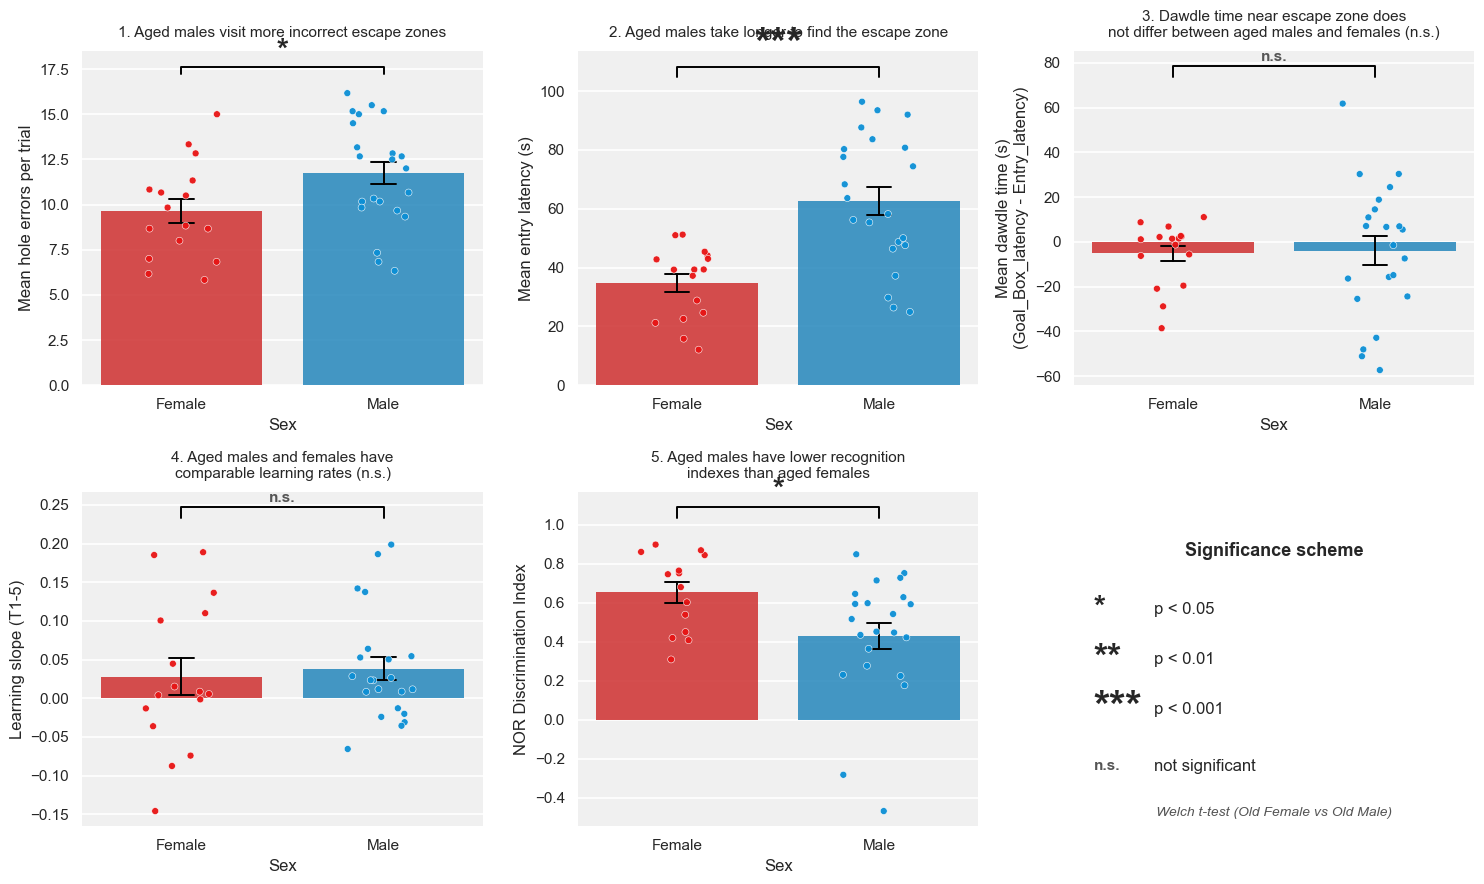


Welch t-test results (Old Female vs Old Male):
  Hole errors           p = 0.0277
  Entry latency         p = 0.0000
  Dawdle time           p = 0.8692
  Learning slope        p = 0.7111
  NOR DI                p = 0.0135

Mean +/- SEM (old animals):
        Hole_errors        Entry_latency_new        dawdle_time        learning_slope            DI       
               mean    sem              mean    sem        mean    sem           mean    sem   mean    sem
Sex_new                                                                                                   
Female        9.646  0.662            34.862  3.080      -5.168  3.565          0.028  0.024  0.653  0.053
Male         11.727  0.616            62.679  4.759      -3.955  6.387          0.038  0.015  0.428  0.068


In [7]:
# Build per-mouse summaries for Barnes (mean across trials) and NOR.
barnes = pd.read_csv(REPO / "Barnes_clean.csv")
barnes["dawdle_time"] = barnes["Goal_Box_latency_new"] - barnes["Entry_latency_new"]

barnes_per_mouse = (barnes.groupby(["ID", "Sex_new", "Age_new"])
    [["Hole_errors", "Entry_latency_new", "dawdle_time"]]
    .mean().reset_index())

nor = pd.read_csv(REPO / "UCBAge_Novel_clean.csv").rename(columns={"Animal_ID": "ID"})
nor["DI"] = (nor["N_obj_nose_duration_s"] - nor["F_obj_nose_duration_s"]) / (
    nor["N_obj_nose_duration_s"] + nor["F_obj_nose_duration_s"])

# Slopes already computed
old = (barnes_per_mouse[barnes_per_mouse["Age_new"] == "Old"]
       .merge(slopes, on="ID", how="left")
       .merge(nor[["ID", "DI"]], on="ID", how="left"))

print(f"Old animals with Barnes per-mouse summary: n = {len(old)}")
print(old.groupby('Sex_new').size().to_string())

def sig_marker(p):
    if not np.isfinite(p): return "n.s."
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."

def plot_old_sex(ax, data, ycol, title, ylabel):
    sub = data.dropna(subset=[ycol, "Sex_new"])
    fem = sub[sub["Sex_new"] == "Female"][ycol].values
    mal = sub[sub["Sex_new"] == "Male"][ycol].values
    if len(fem) >= 2 and len(mal) >= 2:
        t, p = stats.ttest_ind(fem, mal, equal_var=False)
    else:
        t, p = (np.nan, np.nan)

    sns.barplot(data=sub, x="Sex_new", y=ycol, order=["Female", "Male"],
                palette=SEX_COLORS, hue="Sex_new", legend=False,
                errorbar="se", capsize=0.12,
                err_kws={"linewidth": 1.4, "color": "black"},
                edgecolor="none", alpha=0.85, ax=ax)
    sns.stripplot(data=sub, x="Sex_new", y=ycol, order=["Female", "Male"],
                  hue="Sex_new", palette=SEX_COLORS, legend=False,
                  jitter=0.18, size=5, alpha=0.95,
                  edgecolor="white", linewidth=0.4, ax=ax)

    # Significance bracket — bracket always drawn; label is a big asterisk if
    # significant, "n.s." in small text otherwise (matches the circadian-by-sex
    # chart). Numerical p-values are listed in the printed table below the figure.
    ymax = sub[ycol].max(); ymin = sub[ycol].min()
    span = ymax - ymin if ymax > ymin else 1
    y_top = ymax + 0.10 * span
    h = 0.04 * span
    ax.plot([0, 0, 1, 1], [y_top, y_top+h, y_top+h, y_top],
            lw=1.4, color="black")
    marker = sig_marker(p)
    if marker == "n.s.":
        ax.text(0.5, y_top + h*1.2, marker, ha="center", va="bottom",
                fontsize=11, fontweight="bold", color="#555")
    else:
        # Big asterisk(s); size scales slightly with significance level
        size = 22 if marker == "*" else 26 if marker == "**" else 30
        ax.text(0.5, y_top + h*1.2, marker, ha="center", va="bottom",
                fontsize=size, fontweight="bold")

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("Sex"); ax.set_ylabel(ylabel)
    ax.set_facecolor("#f0f0f0")
    for s in ax.spines.values(): s.set_visible(False)
    ax.grid(True, color="white", linewidth=1.2, axis="y")
    return p

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

p1 = plot_old_sex(axes[0,0], old, "Hole_errors",
    "1. Aged males visit more incorrect escape zones",
    "Mean hole errors per trial")
p2 = plot_old_sex(axes[0,1], old, "Entry_latency_new",
    "2. Aged males take longer to find the escape zone",
    "Mean entry latency (s)")
p3 = plot_old_sex(axes[0,2], old, "dawdle_time",
    "3. Dawdle time near escape zone does\nnot differ between aged males and females (n.s.)",
    "Mean dawdle time (s)\n(Goal_Box_latency - Entry_latency)")
p4 = plot_old_sex(axes[1,0], old, "learning_slope",
    "4. Aged males and females have\ncomparable learning rates (n.s.)",
    "Learning slope (T1-5)")
p5 = plot_old_sex(axes[1,1], old, "DI",
    "5. Aged males have lower recognition\nindexes than aged females",
    "NOR Discrimination Index")

# Legend panel: significance scheme
legend_ax = axes[1,2]
legend_ax.axis("off")
legend_ax.text(0.5, 0.85, "Significance scheme",
               ha="center", va="top", transform=legend_ax.transAxes,
               fontsize=13, fontweight="bold")
legend_ax.text(0.05, 0.65, "*",  fontsize=22, fontweight="bold",
               transform=legend_ax.transAxes, va="center")
legend_ax.text(0.20, 0.65, "p < 0.05",
               fontsize=12, transform=legend_ax.transAxes, va="center")
legend_ax.text(0.05, 0.50, "**", fontsize=26, fontweight="bold",
               transform=legend_ax.transAxes, va="center")
legend_ax.text(0.20, 0.50, "p < 0.01",
               fontsize=12, transform=legend_ax.transAxes, va="center")
legend_ax.text(0.05, 0.35, "***", fontsize=30, fontweight="bold",
               transform=legend_ax.transAxes, va="center")
legend_ax.text(0.20, 0.35, "p < 0.001",
               fontsize=12, transform=legend_ax.transAxes, va="center")
legend_ax.text(0.05, 0.18, "n.s.", fontsize=11, fontweight="bold",
               transform=legend_ax.transAxes, va="center", color="#555")
legend_ax.text(0.20, 0.18, "not significant",
               fontsize=12, transform=legend_ax.transAxes, va="center")
legend_ax.text(0.5, 0.04, "Welch t-test (Old Female vs Old Male)",
               ha="center", va="center", transform=legend_ax.transAxes,
               fontsize=10, color="#555", style="italic")

plt.tight_layout()
plt.show()

print("\nWelch t-test results (Old Female vs Old Male):")
for label, p in [("Hole errors", p1), ("Entry latency", p2),
                 ("Dawdle time", p3), ("Learning slope", p4),
                 ("NOR DI", p5)]:
    print(f"  {label:20s}  p = {p:.4f}")

print("\nMean +/- SEM (old animals):")
print(old.groupby('Sex_new')[
    ['Hole_errors','Entry_latency_new','dawdle_time','learning_slope','DI']
].agg(['mean','sem']).round(3).to_string())


## 6. Same 5 endpoints — split by Sex *and* circadian classification

Each panel now has four bars: Female-Resilient, Female-Vulnerable, Male-Resilient,
Male-Vulnerable. Bar = mean, error bars = SEM, dots = individual mice.

For each panel a **two-way ANOVA (Type III)** is run with main effects for Sex
and circadian group, plus the Sex x Group interaction. The three p-values
(Sex / Group / Interaction) are summarised in the small annotation in each
panel using the same asterisk scheme as Section 5
(`*` p<0.05, `**` p<0.01, `***` p<0.001, `n.s.` otherwise).


Old animals with circadian_group: n = 38
Sex_new  circadian_group
Female   Resilient          11
         Vulnerable          5
Male     Resilient           7
         Vulnerable         15


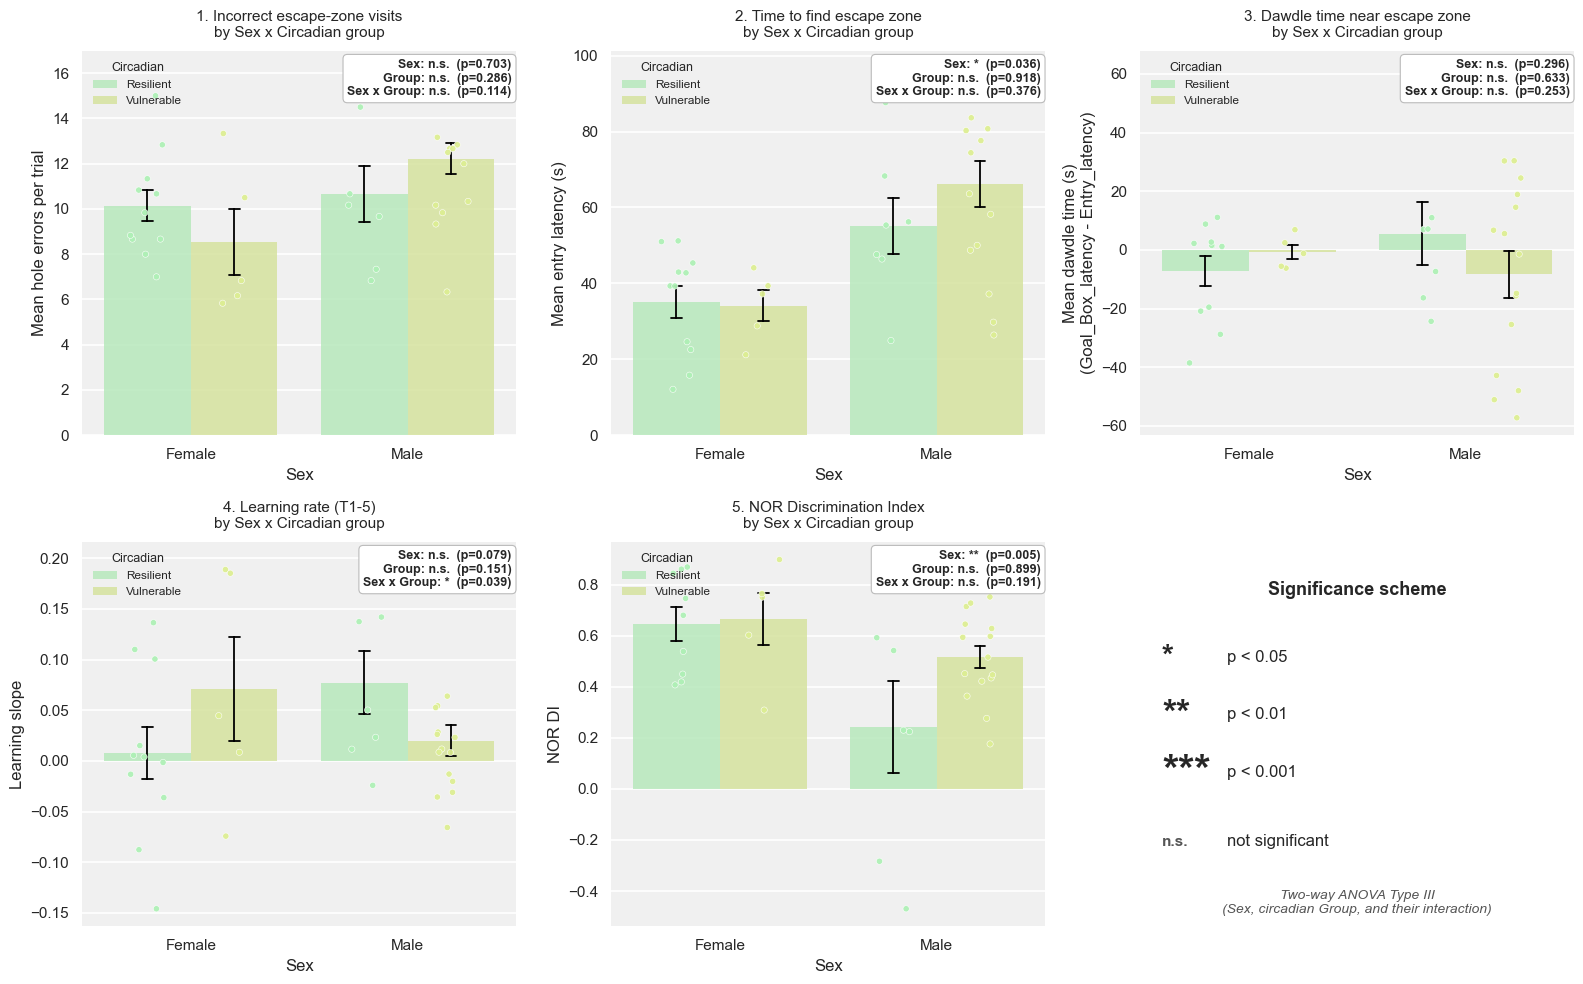


Two-way ANOVA p-values per metric:
  Hole errors         Sex p=0.7026  Group p=0.2859  Sex*Group p=0.1142
  Entry latency       Sex p=0.0356  Group p=0.9185  Sex*Group p=0.3758
  Dawdle time         Sex p=0.2956  Group p=0.6334  Sex*Group p=0.2533
  Learning slope      Sex p=0.0794  Group p=0.1505  Sex*Group p=0.0393
  NOR DI              Sex p=0.0049  Group p=0.8993  Sex*Group p=0.1911

Cell means (Sex x circadian_group) for old animals:
                        Hole_errors              Entry_latency_new              dawdle_time               learning_slope                  DI             
                               mean    sem count              mean    sem count        mean     sem count           mean    sem count   mean    sem count
Sex_new circadian_group                                                                                                                                  
Female  Resilient            10.152  0.698    11            35.191  4.202    11      -7.176   

In [8]:
# Merge circadian_group into the Old animals' summary frame.
groups = df[["ID", "circadian_group"]].drop_duplicates()
old_g = old.merge(groups, on="ID", how="left").dropna(subset=["circadian_group"])
print(f"Old animals with circadian_group: n = {len(old_g)}")
print(old_g.groupby(['Sex_new','circadian_group']).size().to_string())

def anova_two_way(data, ycol):
    sub = data.dropna(subset=[ycol, "Sex_new", "circadian_group"])
    if sub["Sex_new"].nunique() < 2 or sub["circadian_group"].nunique() < 2:
        return {"Sex": np.nan, "Group": np.nan, "Interaction": np.nan}
    mod = smf.ols(f"{ycol} ~ C(Sex_new) * C(circadian_group)", data=sub).fit()
    a = sm.stats.anova_lm(mod, typ=3)
    return {"Sex": a.loc["C(Sex_new)", "PR(>F)"],
            "Group": a.loc["C(circadian_group)", "PR(>F)"],
            "Interaction": a.loc["C(Sex_new):C(circadian_group)", "PR(>F)"]}

def _ast(p):
    if not np.isfinite(p): return "n.s."
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."

def plot_old_sex_x_group(ax, data, ycol, title, ylabel):
    sub = data.dropna(subset=[ycol, "Sex_new", "circadian_group"])

    sns.barplot(data=sub, x="Sex_new", y=ycol, hue="circadian_group",
                order=ORDER_X, hue_order=ORDER_HUE, palette=PALETTE,
                errorbar="se", capsize=0.10,
                err_kws={"linewidth": 1.3, "color": "black"},
                edgecolor="none", alpha=0.85, ax=ax)
    sns.stripplot(data=sub, x="Sex_new", y=ycol, hue="circadian_group",
                  order=ORDER_X, hue_order=ORDER_HUE, palette=PALETTE,
                  dodge=True, jitter=0.16, size=4.5, alpha=0.95,
                  edgecolor="white", linewidth=0.4, ax=ax, legend=False)

    ps = anova_two_way(sub, ycol)

    # Build the annotation: Sex / Group / Interaction with stars or n.s.
    def _line(label, p):
        marker = _ast(p)
        if marker == "n.s.":
            return f"{label}: n.s.  (p={p:.3f})" if np.isfinite(p) else f"{label}: -"
        return f"{label}: {marker}  (p={p:.3f})"

    text = "\n".join([
        _line("Sex",         ps["Sex"]),
        _line("Group",       ps["Group"]),
        _line("Sex x Group", ps["Interaction"]),
    ])
    ax.text(0.99, 0.98, text, transform=ax.transAxes, ha="right", va="top",
            fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                      edgecolor="#bbbbbb", linewidth=0.8))

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("Sex"); ax.set_ylabel(ylabel)
    ax.set_facecolor("#f0f0f0")
    for s in ax.spines.values(): s.set_visible(False)
    ax.grid(True, color="white", linewidth=1.2, axis="y")
    h, l = ax.get_legend_handles_labels()
    ax.legend(h[:2], l[:2], title="Circadian", loc="upper left",
              frameon=False, fontsize=8.5, title_fontsize=9)
    return ps

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ps1 = plot_old_sex_x_group(axes[0,0], old_g, "Hole_errors",
    "1. Incorrect escape-zone visits\nby Sex x Circadian group",
    "Mean hole errors per trial")
ps2 = plot_old_sex_x_group(axes[0,1], old_g, "Entry_latency_new",
    "2. Time to find escape zone\nby Sex x Circadian group",
    "Mean entry latency (s)")
ps3 = plot_old_sex_x_group(axes[0,2], old_g, "dawdle_time",
    "3. Dawdle time near escape zone\nby Sex x Circadian group",
    "Mean dawdle time (s)\n(Goal_Box_latency - Entry_latency)")
ps4 = plot_old_sex_x_group(axes[1,0], old_g, "learning_slope",
    "4. Learning rate (T1-5)\nby Sex x Circadian group",
    "Learning slope")
ps5 = plot_old_sex_x_group(axes[1,1], old_g, "DI",
    "5. NOR Discrimination Index\nby Sex x Circadian group",
    "NOR DI")

# Legend panel: significance scheme (matches Section 5)
legend_ax = axes[1,2]
legend_ax.axis("off")
legend_ax.text(0.5, 0.90, "Significance scheme",
               ha="center", va="top", transform=legend_ax.transAxes,
               fontsize=13, fontweight="bold")
legend_ax.text(0.05, 0.70, "*",  fontsize=22, fontweight="bold",
               transform=legend_ax.transAxes, va="center")
legend_ax.text(0.20, 0.70, "p < 0.05",
               fontsize=12, transform=legend_ax.transAxes, va="center")
legend_ax.text(0.05, 0.55, "**", fontsize=26, fontweight="bold",
               transform=legend_ax.transAxes, va="center")
legend_ax.text(0.20, 0.55, "p < 0.01",
               fontsize=12, transform=legend_ax.transAxes, va="center")
legend_ax.text(0.05, 0.40, "***", fontsize=30, fontweight="bold",
               transform=legend_ax.transAxes, va="center")
legend_ax.text(0.20, 0.40, "p < 0.001",
               fontsize=12, transform=legend_ax.transAxes, va="center")
legend_ax.text(0.05, 0.22, "n.s.", fontsize=11, fontweight="bold",
               transform=legend_ax.transAxes, va="center", color="#555")
legend_ax.text(0.20, 0.22, "not significant",
               fontsize=12, transform=legend_ax.transAxes, va="center")
legend_ax.text(0.5, 0.06,
               "Two-way ANOVA Type III\n(Sex, circadian Group, and their interaction)",
               ha="center", va="center", transform=legend_ax.transAxes,
               fontsize=10, color="#555", style="italic")

plt.tight_layout(); plt.show()

print("\nTwo-way ANOVA p-values per metric:")
for label, ps in [("Hole errors", ps1), ("Entry latency", ps2),
                  ("Dawdle time", ps3), ("Learning slope", ps4),
                  ("NOR DI", ps5)]:
    print(f"  {label:18s}  Sex p={ps['Sex']:.4f}  Group p={ps['Group']:.4f}  "
          f"Sex*Group p={ps['Interaction']:.4f}")

print("\nCell means (Sex x circadian_group) for old animals:")
print(old_g.groupby(['Sex_new','circadian_group'])[
    ['Hole_errors','Entry_latency_new','dawdle_time','learning_slope','DI']
].agg(['mean','sem','count']).round(3).to_string())


## 7. Extend circadian classification to young animals — split by sex

We re-run the same **directional composite z-score, median-split** classification
*within each age group* (Old and Young). That way "Resilient" and "Vulnerable"
mean the same thing inside each cohort and we don't have young animals
auto-classified as resilient just because old animals are sicker on average.

Two figures, 5 endpoints each:

- **Figure A** - Males: Old Resilient | Old Vulnerable | Young Resilient | Young Vulnerable
- **Figure B** - Females: same layout

Per panel: 2-way ANOVA (Age x circadian_group) with the same asterisk scheme.


In [9]:
# ---- 1. Recompute circadian classification within Old and Young separately ----
circ = pd.read_csv(REPO / "Circadian_raw.csv").rename(columns={"PRE.POST": "PRE_POST"})
metrics_base = ["IS", "IV", "RA", "Amplitude"]
wide_circ = circ.pivot_table(index="ID", columns="PRE_POST", values=metrics_base)
wide_circ.columns = [f"{m}_{p.lower()}" for m, p in wide_circ.columns]
wide_circ = wide_circ.reset_index()

grp_meta = (circ[["ID", "Sex_new", "Age_new", "Light_new"]]
            .drop_duplicates(subset="ID").reset_index(drop=True))
wide_circ = wide_circ.merge(grp_meta, on="ID", how="left")

CIRC_METRICS = ["IS_pre","IS_post","IV_pre","IV_post",
                "RA_pre","RA_post","Amplitude_pre","Amplitude_post"]
DIRECTION = {"IS_pre": -1, "IS_post": -1,
             "IV_pre": +1, "IV_post": +1,
             "RA_pre": -1, "RA_post": -1,
             "Amplitude_pre": -1, "Amplitude_post": -1}

def classify_within_age(sub):
    sub = sub.copy()
    z = sub[CIRC_METRICS].apply(stats.zscore, nan_policy="omit")
    for m, sign in DIRECTION.items():
        z[m] = sign * z[m]   # higher = more dysfunction
    sub["dysfunction_score"] = z.mean(axis=1)
    thr = sub["dysfunction_score"].median()
    sub["circadian_group"] = np.where(sub["dysfunction_score"] > thr,
                                       "Vulnerable", "Resilient")
    sub.loc[sub["dysfunction_score"].isna(), "circadian_group"] = np.nan
    return sub

age_classified = []
for age in ["Old", "Young"]:
    a = wide_circ[wide_circ["Age_new"] == age]
    if len(a) == 0:
        continue
    age_classified.append(classify_within_age(a))
classified = pd.concat(age_classified, ignore_index=True)

print("Within-age classification counts:")
print(classified.groupby(['Age_new','Sex_new','circadian_group']).size().to_string())

# ---- 2. Build per-mouse endpoint frame (Old + Young) ----
barnes_full = pd.read_csv(REPO / "Barnes_clean.csv")
barnes_full["dawdle_time"] = barnes_full["Goal_Box_latency_new"] - barnes_full["Entry_latency_new"]
barnes_pm = (barnes_full.groupby(["ID", "Sex_new", "Age_new"])
    [["Hole_errors", "Entry_latency_new", "dawdle_time"]]
    .mean().reset_index())

nor_full = pd.read_csv(REPO / "UCBAge_Novel_clean.csv").rename(columns={"Animal_ID": "ID"})
nor_full["DI"] = (nor_full["N_obj_nose_duration_s"] - nor_full["F_obj_nose_duration_s"]) / (
    nor_full["N_obj_nose_duration_s"] + nor_full["F_obj_nose_duration_s"])

per_mouse = (barnes_pm
             .merge(slopes, on="ID", how="left")
             .merge(nor_full[["ID", "DI"]], on="ID", how="left")
             .merge(classified[["ID", "circadian_group", "dysfunction_score"]],
                    on="ID", how="left"))
per_mouse = per_mouse[per_mouse["Age_new"].isin(["Old", "Young"])].dropna(
    subset=["circadian_group"])

print(f"\nPer-mouse rows for Section 7: n = {len(per_mouse)}")
print(per_mouse.groupby(['Sex_new','Age_new','circadian_group']).size().to_string())


Within-age classification counts:
Age_new  Sex_new  circadian_group
Old      Female   Resilient          13
                  Vulnerable          5
         Male     Resilient           7
                  Vulnerable         15
Young    Female   Resilient           3
                  Vulnerable          2
         Male     Resilient           2
                  Vulnerable          3

Per-mouse rows for Section 7: n = 48
Sex_new  Age_new  circadian_group
Female   Old      Resilient          11
                  Vulnerable          5
         Young    Resilient           3
                  Vulnerable          2
Male     Old      Resilient           7
                  Vulnerable         15
         Young    Resilient           2
                  Vulnerable          3


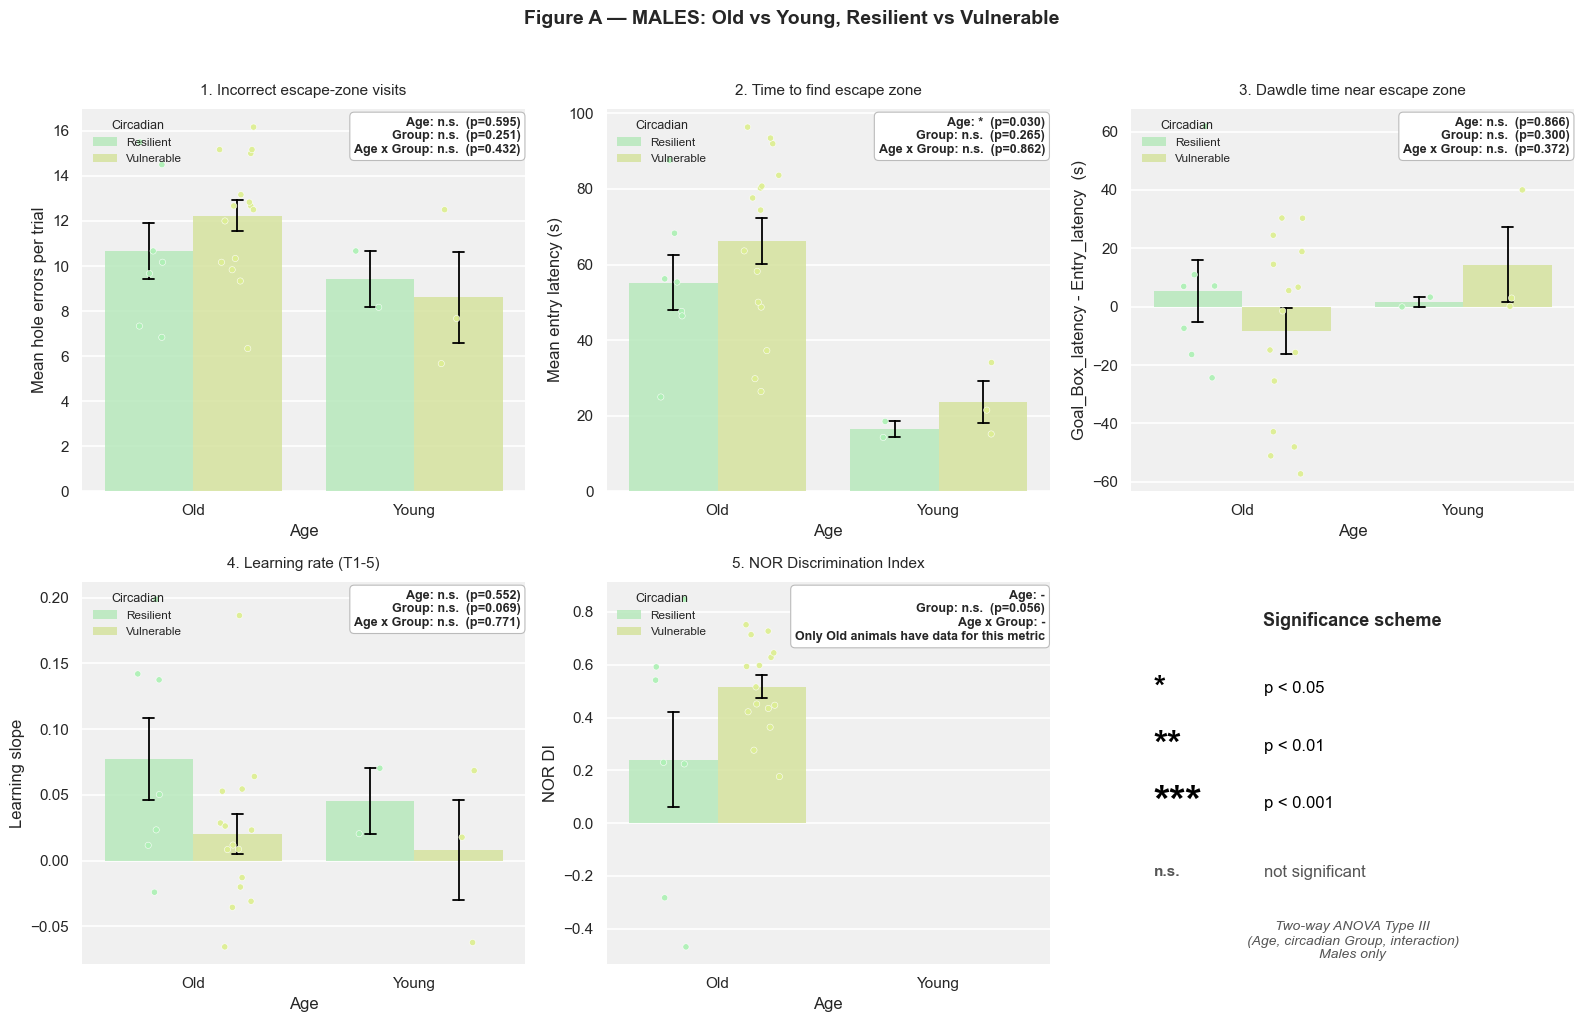

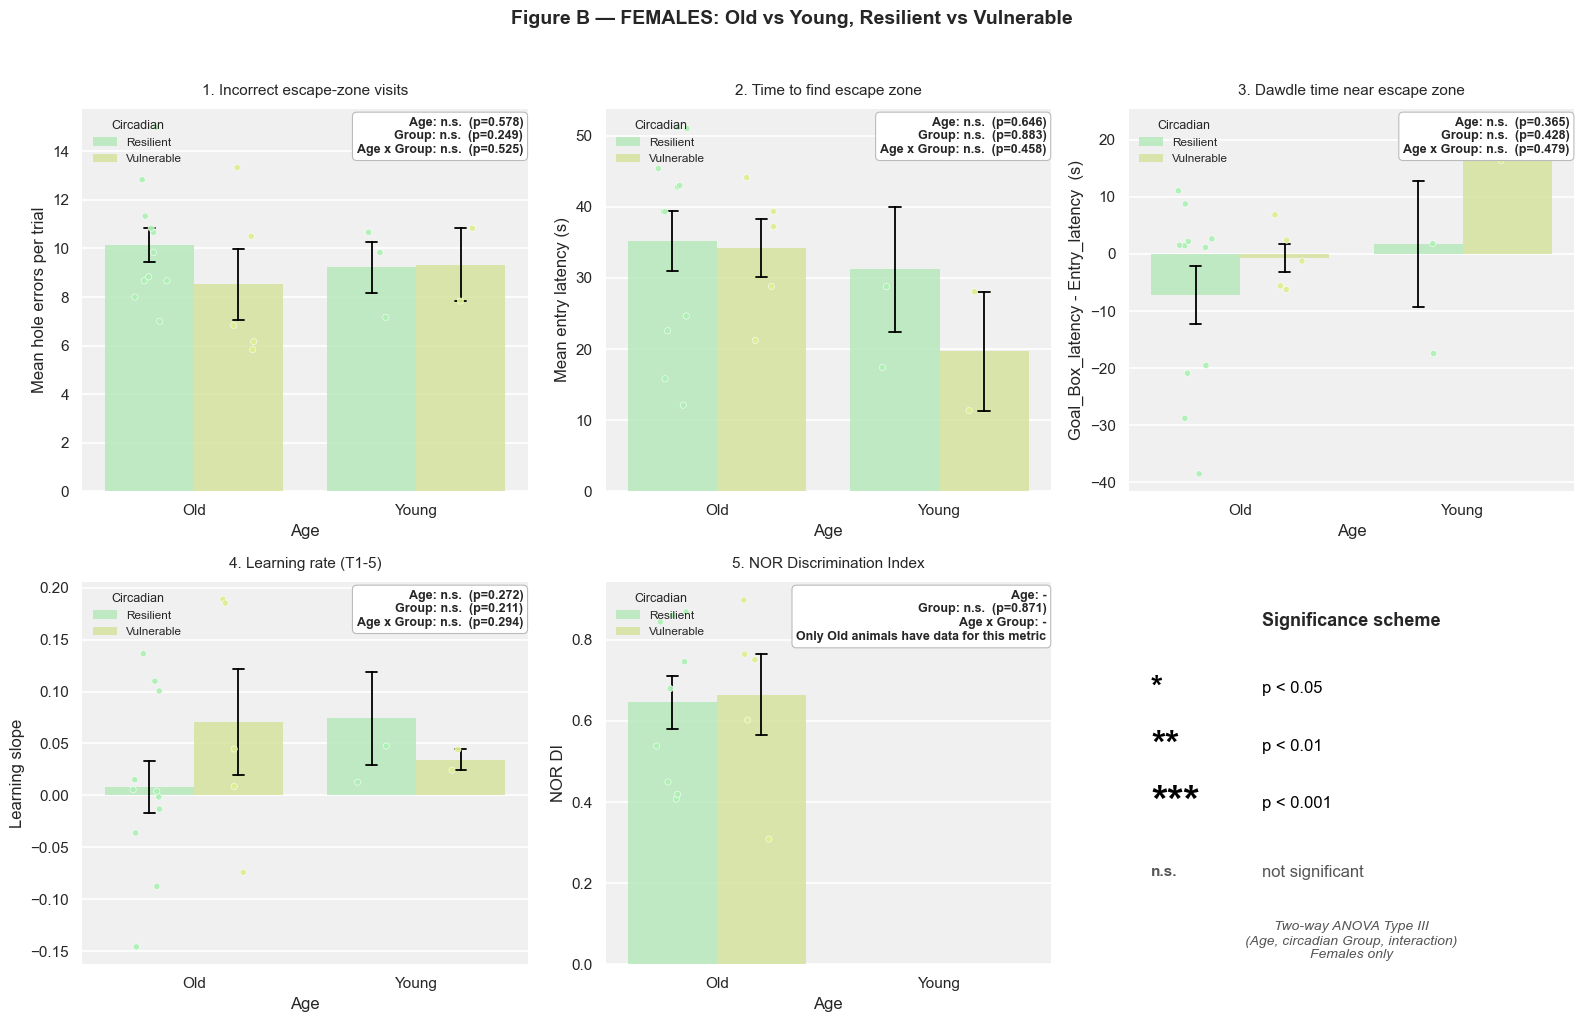


MALES — 2-way ANOVA p-values (Age x circadian_group):
  Hole errors         Age p=0.5945  Group p=0.2514  Age*Group p=0.4316
  Entry latency       Age p=0.0300  Group p=0.2647  Age*Group p=0.8619
  Dawdle time         Age p=0.8661  Group p=0.3000  Age*Group p=0.3717
  Learning slope      Age p=0.5522  Group p=0.0695  Age*Group p=0.7711
  NOR DI              Age p=nan  Group p=0.0561  Age*Group p=nan

FEMALES — 2-way ANOVA p-values (Age x circadian_group):
  Hole errors         Age p=0.5779  Group p=0.2492  Age*Group p=0.5253
  Entry latency       Age p=0.6463  Group p=0.8826  Age*Group p=0.4576
  Dawdle time         Age p=0.3652  Group p=0.4279  Age*Group p=0.4787
  Learning slope      Age p=0.2717  Group p=0.2109  Age*Group p=0.2945
  NOR DI              Age p=nan  Group p=0.8714  Age*Group p=nan


In [10]:
# ---- 3. Plot helper: x = Age, hue = circadian_group, 2-way ANOVA per panel ----
AGE_ORDER_2 = ["Old", "Young"]

def plot_age_x_group(ax, data, ycol, title, ylabel):
    sub = data.dropna(subset=[ycol, "Age_new", "circadian_group"])
    if len(sub) == 0:
        ax.set_axis_off(); return {"Age": np.nan, "Group": np.nan, "Interaction": np.nan}

    sns.barplot(data=sub, x="Age_new", y=ycol, hue="circadian_group",
                order=AGE_ORDER_2, hue_order=ORDER_HUE, palette=PALETTE,
                errorbar="se", capsize=0.10,
                err_kws={"linewidth": 1.3, "color": "black"},
                edgecolor="none", alpha=0.85, ax=ax)
    sns.stripplot(data=sub, x="Age_new", y=ycol, hue="circadian_group",
                  order=AGE_ORDER_2, hue_order=ORDER_HUE, palette=PALETTE,
                  dodge=True, jitter=0.16, size=4.5, alpha=0.95,
                  edgecolor="white", linewidth=0.4, ax=ax, legend=False)

    # ANOVA: 2-way if both ages present; else 1-way on Group with a note.
    only_one_age = sub["Age_new"].nunique() < 2
    note = None
    if sub["circadian_group"].nunique() < 2:
        ps = {"Age": np.nan, "Group": np.nan, "Interaction": np.nan}
    elif only_one_age:
        ages_present = sub["Age_new"].unique().tolist()
        note = f"Only {ages_present[0]} animals have data for this metric"
        # one-way: Group only
        m1 = smf.ols(f"{ycol} ~ C(circadian_group)", data=sub).fit()
        a1 = sm.stats.anova_lm(m1, typ=3)
        ps = {"Age": np.nan,
              "Group": a1.loc["C(circadian_group)", "PR(>F)"],
              "Interaction": np.nan}
    else:
        mod = smf.ols(f"{ycol} ~ C(Age_new) * C(circadian_group)", data=sub).fit()
        a   = sm.stats.anova_lm(mod, typ=3)
        ps  = {"Age": a.loc["C(Age_new)", "PR(>F)"],
               "Group": a.loc["C(circadian_group)", "PR(>F)"],
               "Interaction": a.loc["C(Age_new):C(circadian_group)", "PR(>F)"]}

    def _line(label, p):
        if not np.isfinite(p): return f"{label}: -"
        m = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        return f"{label}: {m}  (p={p:.3f})"

    lines = [_line("Age", ps["Age"]),
             _line("Group", ps["Group"]),
             _line("Age x Group", ps["Interaction"])]
    if note: lines.append(note)
    ax.text(0.99, 0.98, "\n".join(lines),
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                      edgecolor="#bbbbbb", linewidth=0.8))

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("Age"); ax.set_ylabel(ylabel)
    ax.set_facecolor("#f0f0f0")
    for s in ax.spines.values(): s.set_visible(False)
    ax.grid(True, color="white", linewidth=1.2, axis="y")
    h, l = ax.get_legend_handles_labels()
    ax.legend(h[:2], l[:2], title="Circadian", loc="upper left",
              frameon=False, fontsize=8.5, title_fontsize=9)
    return ps

def add_legend_panel(ax, footer):
    ax.axis("off")
    ax.text(0.5, 0.92, "Significance scheme", ha="center", va="top",
            transform=ax.transAxes, fontsize=13, fontweight="bold")
    rows = [("*",  22, "p < 0.05",   0.72, "black"),
            ("**", 26, "p < 0.01",   0.57, "black"),
            ("***",30, "p < 0.001",  0.42, "black"),
            ("n.s.",11,"not significant", 0.24, "#555")]
    for sym, sz, txt, y, color in rows:
        ax.text(0.05, y, sym, fontsize=sz, fontweight="bold",
                transform=ax.transAxes, va="center", color=color)
        ax.text(0.30, y, txt, fontsize=12,
                transform=ax.transAxes, va="center", color=color)
    ax.text(0.5, 0.06, footer, ha="center", va="center",
            transform=ax.transAxes, fontsize=10, color="#555", style="italic")

# ---- Figure A: MALES ----
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Figure A — MALES: Old vs Young, Resilient vs Vulnerable",
             fontsize=14, fontweight="bold", y=1.02)

males = per_mouse[per_mouse["Sex_new"] == "Male"]
m_ps = {}
m_ps["1"] = plot_age_x_group(axes[0,0], males, "Hole_errors",
    "1. Incorrect escape-zone visits",
    "Mean hole errors per trial")
m_ps["2"] = plot_age_x_group(axes[0,1], males, "Entry_latency_new",
    "2. Time to find escape zone",
    "Mean entry latency (s)")
m_ps["3"] = plot_age_x_group(axes[0,2], males, "dawdle_time",
    "3. Dawdle time near escape zone",
    "Goal_Box_latency - Entry_latency  (s)")
m_ps["4"] = plot_age_x_group(axes[1,0], males, "learning_slope",
    "4. Learning rate (T1-5)",
    "Learning slope")
m_ps["5"] = plot_age_x_group(axes[1,1], males, "DI",
    "5. NOR Discrimination Index",
    "NOR DI")
add_legend_panel(axes[1,2],
    "Two-way ANOVA Type III\n(Age, circadian Group, interaction)\nMales only")
plt.tight_layout(); plt.show()

# ---- Figure B: FEMALES ----
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Figure B — FEMALES: Old vs Young, Resilient vs Vulnerable",
             fontsize=14, fontweight="bold", y=1.02)

females = per_mouse[per_mouse["Sex_new"] == "Female"]
f_ps = {}
f_ps["1"] = plot_age_x_group(axes[0,0], females, "Hole_errors",
    "1. Incorrect escape-zone visits",
    "Mean hole errors per trial")
f_ps["2"] = plot_age_x_group(axes[0,1], females, "Entry_latency_new",
    "2. Time to find escape zone",
    "Mean entry latency (s)")
f_ps["3"] = plot_age_x_group(axes[0,2], females, "dawdle_time",
    "3. Dawdle time near escape zone",
    "Goal_Box_latency - Entry_latency  (s)")
f_ps["4"] = plot_age_x_group(axes[1,0], females, "learning_slope",
    "4. Learning rate (T1-5)",
    "Learning slope")
f_ps["5"] = plot_age_x_group(axes[1,1], females, "DI",
    "5. NOR Discrimination Index",
    "NOR DI")
add_legend_panel(axes[1,2],
    "Two-way ANOVA Type III\n(Age, circadian Group, interaction)\nFemales only")
plt.tight_layout(); plt.show()

# ---- Print all p-values ----
LABELS = {"1":"Hole errors","2":"Entry latency","3":"Dawdle time",
          "4":"Learning slope","5":"NOR DI"}
print("\nMALES — 2-way ANOVA p-values (Age x circadian_group):")
for k, label in LABELS.items():
    p = m_ps[k]
    print(f"  {label:18s}  Age p={p['Age']:.4f}  Group p={p['Group']:.4f}  "
          f"Age*Group p={p['Interaction']:.4f}")
print("\nFEMALES — 2-way ANOVA p-values (Age x circadian_group):")
for k, label in LABELS.items():
    p = f_ps[k]
    print(f"  {label:18s}  Age p={p['Age']:.4f}  Group p={p['Group']:.4f}  "
          f"Age*Group p={p['Interaction']:.4f}")
